# QTran：冻结当前结果与第一轮低成本筛选

本 Notebook 不覆盖原始三数据集正式实验。它只完成两件事：

1. 将已经完成的 MixedWM38 四模型五种子结果完整复制到独立目录，并生成 SHA-256 完整性清单；
2. 在新的数据划分上仅训练 Quantum Transformer，使用验证集比较 12 个稳定性配置，全程不计算测试集指标。

筛选标准固定为：`验证 Macro-F1 均值 - 0.5 × 跨种子标准差`。测试集必须等到配置完全锁定后才能评价。

## 0. 运行顺序

依次运行全部单元格。冻结单元可以重复执行，但不会覆盖快照，只会校验文件哈希。筛选单元按“配置 × 种子”保存，可以在 Kernel 中断后直接重新执行并续跑。

预计任务量为 12 个配置 × 3 个开发种子 = 36 次量子模型训练。

In [1]:
from dataclasses import replace
from pathlib import Path
import sys

import matplotlib.pyplot as plt
from matplotlib.ticker import FormatStrFormatter
import pandas as pd
from IPython.display import display

PROJECT_DIR = Path.cwd().resolve()
if not (PROJECT_DIR / 'qcs_wm811k.py').exists() and (PROJECT_DIR / 'QCS' / 'qcs_wm811k.py').exists():
    PROJECT_DIR = PROJECT_DIR / 'QCS'
if str(PROJECT_DIR) not in sys.path:
    sys.path.insert(0, str(PROJECT_DIR))

from qcs_core import ExperimentConfig, environment_report
from qcs_datasets import load_dataset_cache
from qcs_screening import (
    freeze_completed_run,
    run_validation_screen,
    summarize_validation_screen,
    verify_frozen_run,
)

print('PROJECT_DIR:', PROJECT_DIR)
print(environment_report())

/root/xxx/autodl/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


PROJECT_DIR: /root/xxx/autodl
{'torch': '2.7.1+cu118', 'deepquantum': '4.5.0', 'cuda_available': True, 'cuda_device': 'NVIDIA GeForce RTX 4090'}


In [2]:
CACHE_PATH = PROJECT_DIR / 'data_cache' / 'mixedwm38_32.npz'

# 原正式实验的位置：与三数据集 Notebook 中的 ARTIFACT_ROOT 保持一致。
CURRENT_ARTIFACT_ROOT = PROJECT_DIR / 'artifacts' / 'three_datasets_five_projection'
CURRENT_RUN_DIR = CURRENT_ARTIFACT_ROOT / 'mixedwm38'

# V1 快照只创建一次，此后只能校验，不能由本 Notebook 覆盖。
FROZEN_DIR = (
    PROJECT_DIR / 'artifacts' / 'frozen_results_v1'
    / 'mixedwm38_seeds_42_52_62_72_82'
)

# 第一轮筛选使用独立目录，不会与正式结果混合。
SCREEN_ROOT = PROJECT_DIR / 'artifacts' / 'stability_search_v2'

print('CACHE_PATH exists:', CACHE_PATH.exists(), CACHE_PATH)
print('CURRENT_RUN_DIR exists:', CURRENT_RUN_DIR.exists(), CURRENT_RUN_DIR)
print('FROZEN_DIR:', FROZEN_DIR)
print('SCREEN_ROOT:', SCREEN_ROOT)

assert CACHE_PATH.exists(), CACHE_PATH
assert (CURRENT_RUN_DIR / 'comparison_results.csv').exists(), CURRENT_RUN_DIR

CACHE_PATH exists: True /root/xxx/autodl/data_cache/mixedwm38_32.npz
CURRENT_RUN_DIR exists: True /root/xxx/autodl/artifacts/three_datasets_five_projection/mixedwm38
FROZEN_DIR: /root/xxx/autodl/artifacts/frozen_results_v1/mixedwm38_seeds_42_52_62_72_82
SCREEN_ROOT: /root/xxx/autodl/artifacts/stability_search_v2


## 1. 冻结当前 MixedWM38 五种子结果

In [3]:
freeze_completed_run(
    source_run_dir=CURRENT_RUN_DIR,
    frozen_dir=FROZEN_DIR,
    seeds=(42, 52, 62, 72, 82),
)

frozen_results = verify_frozen_run(FROZEN_DIR)
print('冻结结果行数:', len(frozen_results), '/ 20')

frozen_summary = (
    frozen_results.groupby('model')
    .agg(
        test_macro_f1_mean=('macro_f1', 'mean'),
        test_macro_f1_std=('macro_f1', 'std'),
        balanced_acc_mean=('balanced_accuracy', 'mean'),
        balanced_acc_std=('balanced_accuracy', 'std'),
        train_seconds_mean=('train_seconds', 'mean'),
        parameters=('parameters', 'first'),
    )
    .sort_values('test_macro_f1_mean', ascending=False)
)
display(frozen_summary.round(3))
print('完整性清单:', FROZEN_DIR / 'frozen_manifest.json')

Frozen snapshot already exists and passed verification: /root/xxx/autodl/artifacts/frozen_results_v1/mixedwm38_seeds_42_52_62_72_82
冻结结果行数: 20 / 20


,test_macro_f1_mean,test_macro_f1_std,balanced_acc_mean,balanced_acc_std,train_seconds_mean,parameters
model,,,,,,
cnn_token_mixer,0.438,0.010,0.458,0.012,348.957,2462
mlp_mixer,0.435,0.009,0.454,0.006,344.582,2504
tiny_transformer,0.423,0.007,0.442,0.010,434.036,2502
quantum_transformer,0.395,0.052,0.414,0.046,2818.683,2446


完整性清单: /root/xxx/autodl/artifacts/frozen_results_v1/mixedwm38_seeds_42_52_62_72_82/frozen_manifest.json


冻结快照包含原目录中的结果表、配置、划分索引、历史、混淆矩阵和检查点。`frozen_manifest.json` 记录每个文件的 SHA-256。重复运行时若任一文件被修改，校验会直接报错。

## 2. 固定第一轮低成本筛选协议

In [4]:
SCREEN_CONFIG = replace(
    ExperimentConfig.publication(),
    quantum_projection_mode='five',
    epochs=30,
    patience=6,
    batch_size=64,
    sampler_power=0.5,
    train_cap_per_class=500,
    eval_cap_per_class=None,
    num_workers=0,
)

DEV_SEEDS = (42, 52, 62)
SCREEN_SPLIT_SEED = 4096
INIT_SCALES = (0.020, 0.050, 0.100)
QUANTUM_LR_MULTIPLIERS = (0.500, 1.000)
PRE_NORM_OPTIONS = (False, True)

print('任务数:', len(DEV_SEEDS) * len(INIT_SCALES) * len(QUANTUM_LR_MULTIPLIERS) * len(PRE_NORM_OPTIONS))
print('开发种子:', DEV_SEEDS)
print('筛选划分种子:', SCREEN_SPLIT_SEED)
print('注意：本阶段不计算任何测试集指标。')

任务数: 36
开发种子: (42, 52, 62)
筛选划分种子: 4096
注意：本阶段不计算任何测试集指标。


### 配置范围

- 初始化尺度：0.020、0.050、0.100；
- 量子参数学习率倍率：0.500、1.000；
- 归一化位置：Post-Norm 与 Pre-Norm；
- 每类最多 500 个训练样本，验证集不截断；
- 每个配置最多 30 轮，耐心值为 6。

本轮只负责排除明显不稳定配置，不产生论文测试结果。

## 3. 运行或续跑36个验证集筛选任务

In [5]:
screen_results = run_validation_screen(
    cache_path=CACHE_PATH,
    base_config=SCREEN_CONFIG,
    artifact_dir=SCREEN_ROOT,
    seeds=DEV_SEEDS,
    split_seed=SCREEN_SPLIT_SEED,
    init_scales=INIT_SCALES,
    lr_multipliers=QUANTUM_LR_MULTIPLIERS,
    pre_norm_options=PRE_NORM_OPTIONS,
    resume=True,
)

print('已完成任务:', len(screen_results), '/ 36')
assert not screen_results['test_evaluated'].astype(bool).any()
display(screen_results.round(3))

Validation-only screen: 12 configurations × 3 seeds = 36 jobs

[init_0p100__qlr_0p500__prenorm_1] seed=62



[init_0p100__qlr_1p000__prenorm_0] seed=42



[init_0p100__qlr_1p000__prenorm_0] seed=52



[init_0p100__qlr_1p000__prenorm_0] seed=62



[init_0p100__qlr_1p000__prenorm_1] seed=42



[init_0p100__qlr_1p000__prenorm_1] seed=52



[init_0p100__qlr_1p000__prenorm_1] seed=62


已完成任务: 36 / 36


,dataset,config_id,seed,quantum_init_scale,quantum_lr_multiplier,quantum_pre_norm,parameters,train_seconds,best_epoch,best_val_macro_f1,val_balanced_accuracy_at_best_f1,train_samples,val_samples,test_evaluated
0,mixedwm38,init_0p020__qlr_0p500__prenorm_0,42,0.02,0.5,False,2446,1366.059,29,0.314,0.354,18604,5702,False
1,mixedwm38,init_0p020__qlr_0p500__prenorm_0,52,0.02,0.5,False,2446,1369.318,29,0.314,0.352,18604,5702,False
2,mixedwm38,init_0p020__qlr_0p500__prenorm_0,62,0.02,0.5,False,2446,1307.057,23,0.244,0.292,18604,5702,False
3,mixedwm38,init_0p020__qlr_0p500__prenorm_1,42,0.02,0.5,True,2446,1613.142,28,0.246,0.288,18604,5702,False
4,mixedwm38,init_0p020__qlr_0p500__prenorm_1,52,0.02,0.5,True,2446,1591.492,25,0.307,0.342,18604,5702,False
5,mixedwm38,init_0p020__qlr_0p500__prenorm_1,62,0.02,0.5,True,2446,1587.156,23,0.122,0.180,18604,5702,False
6,mixedwm38,init_0p020__qlr_1p000__prenorm_0,42,0.02,1.0,False,2446,1517.962,22,0.306,0.343,18604,5702,False
7,mixedwm38,init_0p020__qlr_1p000__prenorm_0,52,0.02,1.0,False,2446,1593.035,27,0.308,0.354,18604,5702,False
8,mixedwm38,init_0p020__qlr_1p000__prenorm_0,62,0.02,1.0,False,2446,1595.192,29,0.217,0.267,18604,5702,False
9,mixedwm38,init_0p020__qlr_1p000__prenorm_1,42,0.02,1.0,True,2446,1548.876,29,0.319,0.368,18604,5702,False


如果训练被中断，重新运行上一个单元格即可。只有同时存在匹配的 `signature.json`、`result.json`、`history.json` 和 `best.pt` 时，任务才会被跳过；被中断的单个任务会从头训练。

## 4. 汇总并选出前两名候选配置

In [6]:
screen_summary = summarize_validation_screen(screen_results)

display(screen_summary.round(3))

top2 = screen_summary.head(2).copy()
print('进入第二轮完整训练的前两名配置：')
display(top2.round(3))

output_dir = SCREEN_ROOT / 'mixedwm38'
screen_results.to_csv(output_dir / 'validation_screen_results.csv', index=False)
screen_summary.to_csv(output_dir / 'validation_screen_summary.csv', index=False)
top2.to_csv(output_dir / 'top2_candidates.csv', index=False)

print('结果目录:', output_dir)

,config_id,seeds,val_macro_f1_mean,val_macro_f1_std,val_balanced_acc_mean,train_seconds_mean,quantum_init_scale,quantum_lr_multiplier,quantum_pre_norm,parameters,selection_score
0,init_0p020__qlr_0p500__prenorm_0,3,0.290,0.040,0.333,1347.478,0.02,0.5,False,2446,0.270
1,init_0p100__qlr_0p500__prenorm_0,3,0.307,0.077,0.351,1521.605,0.10,0.5,False,2446,0.269
2,init_0p100__qlr_1p000__prenorm_0,3,0.311,0.085,0.356,1503.017,0.10,1.0,False,2446,0.268
3,init_0p020__qlr_1p000__prenorm_0,3,0.277,0.052,0.321,1568.730,0.02,1.0,False,2446,0.251
4,init_0p050__qlr_0p500__prenorm_0,3,0.271,0.087,0.314,1422.799,0.05,0.5,False,2446,0.227
5,init_0p050__qlr_1p000__prenorm_0,3,0.270,0.093,0.315,1421.297,0.05,1.0,False,2446,0.224
6,init_0p050__qlr_0p500__prenorm_1,3,0.241,0.082,0.286,1525.194,0.05,0.5,True,2446,0.201
7,init_0p100__qlr_1p000__prenorm_1,3,0.214,0.067,0.269,1502.431,0.10,1.0,True,2446,0.180
8,init_0p020__qlr_0p500__prenorm_1,3,0.225,0.094,0.270,1597.263,0.02,0.5,True,2446,0.178
9,init_0p020__qlr_1p000__prenorm_1,3,0.220,0.103,0.273,1529.734,0.02,1.0,True,2446,0.169


进入第二轮完整训练的前两名配置：


,config_id,seeds,val_macro_f1_mean,val_macro_f1_std,val_balanced_acc_mean,train_seconds_mean,quantum_init_scale,quantum_lr_multiplier,quantum_pre_norm,parameters,selection_score
0,init_0p020__qlr_0p500__prenorm_0,3,0.290,0.040,0.333,1347.478,0.02,0.5,False,2446,0.270
1,init_0p100__qlr_0p500__prenorm_0,3,0.307,0.077,0.351,1521.605,0.10,0.5,False,2446,0.269


结果目录: /root/xxx/autodl/artifacts/stability_search_v2/mixedwm38


## 5. 绘制第一轮筛选结果

findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times Ne

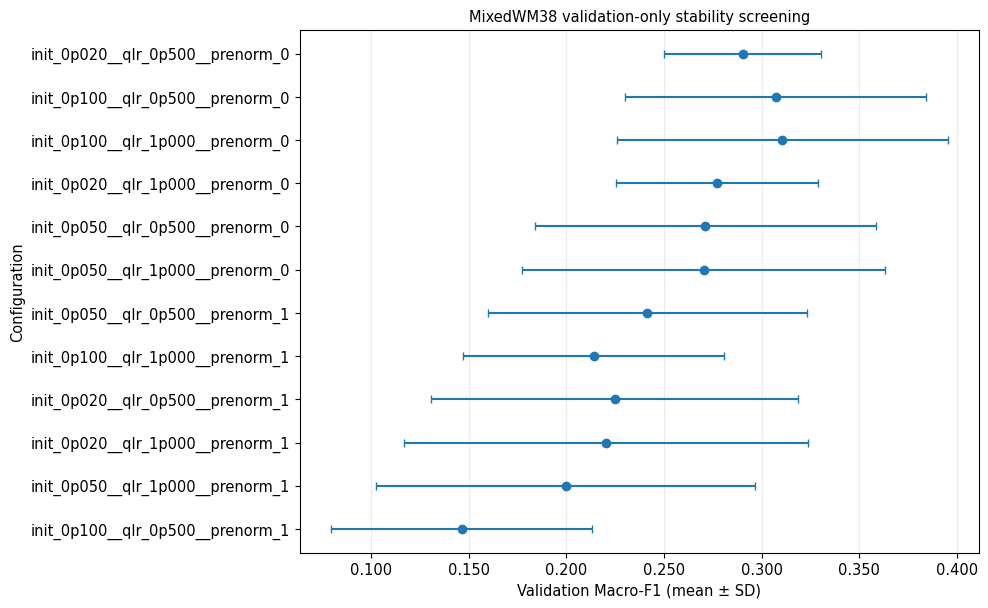

图片已保存: /root/xxx/autodl/artifacts/stability_search_v2/mixedwm38/validation_screen_macro_f1.png


In [7]:
plt.rcParams.update({
    'font.family': 'Times New Roman',
    'font.size': 10.5,
    'axes.titlesize': 10.5,
    'axes.labelsize': 10.5,
    'xtick.labelsize': 10.5,
    'ytick.labelsize': 10.5,
    'legend.fontsize': 10.5,
})

plot_table = screen_summary.sort_values('selection_score', ascending=True)
fig, ax = plt.subplots(figsize=(10.0, 6.2))
ax.errorbar(
    plot_table['val_macro_f1_mean'],
    plot_table['config_id'],
    xerr=plot_table['val_macro_f1_std'],
    fmt='o',
    capsize=3,
)
ax.xaxis.set_major_formatter(FormatStrFormatter('%.3f'))
ax.set_xlabel('Validation Macro-F1 (mean ± SD)')
ax.set_ylabel('Configuration')
ax.set_title('MixedWM38 validation-only stability screening')
ax.grid(axis='x', alpha=0.25)
fig.tight_layout()

figure_path = output_dir / 'validation_screen_macro_f1.png'
fig.savefig(figure_path, dpi=300, bbox_inches='tight')
plt.show()
print('图片已保存:', figure_path)

## 6. 本轮结束条件

完成后应同时得到：

- 冻结快照及 SHA-256 清单；
- 36 行 `validation_screen_results.csv`；
- 12 行 `validation_screen_summary.csv`；
- 2 行 `top2_candidates.csv`；
- 验证集筛选图。

不要在本 Notebook 中运行测试集。下一阶段只对这里选出的两个配置使用五个新种子进行完整验证，然后锁定唯一配置。